# EDA and Dataset Splitting
### Author: Achintya Kattemalavadi (akattema@berkeley.edu)
This notebook contains the code to perform EDA on the GitHub issues and labels dataset and split it into train, validation, and test datasets.

### Imports

In [32]:
# Imports
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

### Load the data
Add it to a Pandas dataframe for ease of exploration.

In [33]:
# Load the data
issues_list = []
issues_list_file = "data/dataset_reformatted_final.json" 
with open(issues_list_file, "r", encoding="utf-8") as f:
    issues_list = json.load(f)

In [3]:
# Load into Pandas dataframe
iss_df = pd.DataFrame(issues_list)
iss_df.head()

,repo_name,issue_id,title,body,comments,accessibility,release,dependency,good_first_issue,webview,...,documentation,featurerequest,feature,help_wanted,test,ui,api,enhancement,regression,security
0,flutter,164890,Consolidate GTK mocks,"This was split across three files, consolidate...",[],False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,flutter,164600,"Reverts ""[Impeller] use DeviceLocal textures f...",<!-- start_original_pr_link -->\nReverts: flut...,[],False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,flutter,164512,"Reverts ""Run run_debug_test_android and run_re...",<!-- start_original_pr_link -->\nReverts: flut...,[],False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,flutter,164491,[web] Detect scrollable semantics nodes more r...,"When a text field is inside a scrollable, and ...",[],True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,flutter,164396,"Reverts ""Write an identical value to `bin/cach...",<!-- start_original_pr_link -->\nReverts: flut...,['Detected the `emergency` label.\n\nIf you ad...,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Display basic details of dataframe

In [4]:
# DF info
print(iss_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112389 entries, 0 to 112388
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   repo_name         112389 non-null  object
 1   issue_id          112389 non-null  object
 2   title             112389 non-null  object
 3   body              112133 non-null  object
 4   comments          112389 non-null  object
 5   accessibility     112389 non-null  bool  
 6   release           112389 non-null  bool  
 7   dependency        112389 non-null  bool  
 8   good_first_issue  112389 non-null  bool  
 9   webview           112389 non-null  bool  
 10  oslinux           112389 non-null  bool  
 11  revert            112389 non-null  bool  
 12  bug               112389 non-null  bool  
 13  documentation     112389 non-null  bool  
 14  featurerequest    112389 non-null  bool  
 15  feature           112389 non-null  bool  
 16  help_wanted       112389 non-null  boo

In [6]:
# DF description
print(iss_df.describe(include="all"))

       repo_name issue_id                                     title    body  \
count     112389   112389                                    112389  112133   
unique        10    86088                                    111204  110702   
top       vscode     1614  chore: npm-check-updates && yarn upgrade           
freq       56286        6                                       234     555   

       comments accessibility release dependency good_first_issue webview  \
count    112389        112389  112389     112389           112389  112389   
unique    91120             2       2          2                2       2   
top          []         False   False      False            False   False   
freq      15769        107591  112123     110431           109951  110717   

        ... documentation featurerequest feature help_wanted    test      ui  \
count   ...        112389         112389  112389      112389  112389  112389   
unique  ...             2              2       2          

### Check null rows and remove

In [7]:
# Check nulls
print(iss_df.isnull().sum())

repo_name             0
issue_id              0
title                 0
body                256
comments              0
accessibility         0
release               0
dependency            0
good_first_issue      0
webview               0
oslinux               0
revert                0
bug                   0
documentation         0
featurerequest        0
feature               0
help_wanted           0
test                  0
ui                    0
api                   0
enhancement           0
regression            0
security              0
dtype: int64


In [5]:
# Drop NAs
iss_df = iss_df.dropna()
print(iss_df.isnull().sum())

repo_name           0
issue_id            0
title               0
body                0
comments            0
accessibility       0
release             0
dependency          0
good_first_issue    0
webview             0
oslinux             0
revert              0
bug                 0
documentation       0
featurerequest      0
feature             0
help_wanted         0
test                0
ui                  0
api                 0
enhancement         0
regression          0
security            0
dtype: int64


### Look at the number of labels per issue distribution

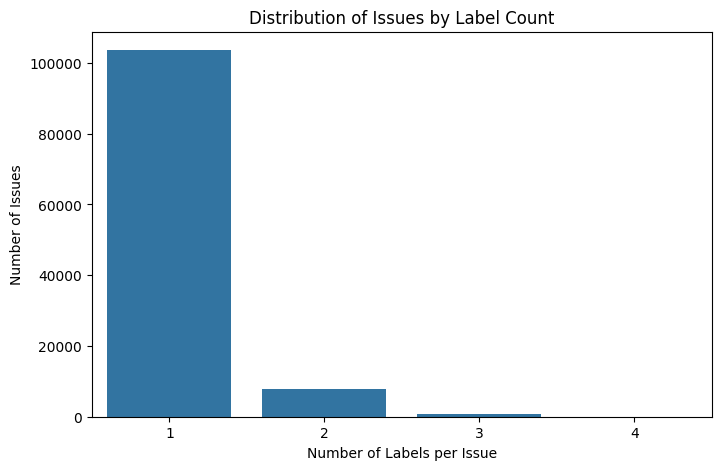

In [34]:
iss_df["label_count"] = iss_df.iloc[:, 5:].sum(axis=1)
lab_count_dist = iss_df["label_count"].value_counts().sort_index()

# Plot the distribution of label counts per issue
plt.figure(figsize=(8, 5))
sns.barplot(x=lab_count_dist.index, y=lab_count_dist.values)
plt.xlabel("Number of Labels per Issue")
plt.ylabel("Number of Issues")
plt.title("Distribution of Issues by Label Count")
plt.xticks(rotation=0)
plt.show()

### Look at distribution of labels in dataset
Need to check for class imbalances.

In [6]:
# Check label distribution
lab_dist = iss_df.iloc[:, 5:].sum().sort_values(ascending=False)
print(lab_dist)

bug                 65098
featurerequest      26947
enhancement          5740
accessibility        4748
revert               3454
good_first_issue     2436
help_wanted          2278
api                  2179
dependency           1957
webview              1665
regression           1075
feature              1006
oslinux               955
documentation         700
test                  611
release               266
ui                    176
security               93
dtype: int64


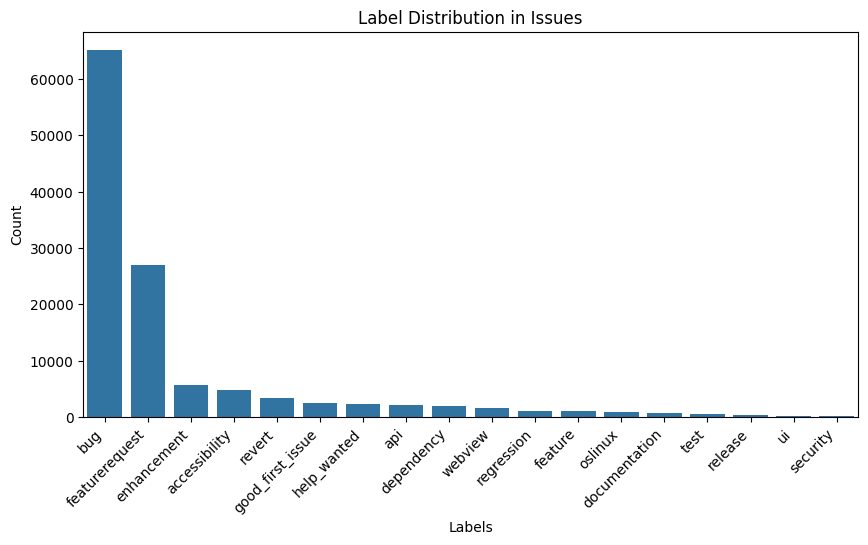

In [7]:
# Plot label distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=lab_dist.index, y=lab_dist.values)
plt.xticks(rotation=45, ha="right")
plt.title("Label Distribution in Issues")
plt.ylabel("Count")
plt.xlabel("Labels")
plt.show()

In [11]:
total_labels = lab_dist.sum()
top_label_percentage = (lab_dist.iloc[0] / total_labels) * 100
top_label_name = lab_dist.index[0]
second_label_percentage = (lab_dist.iloc[1] / total_labels) * 100
second_label_name = lab_dist.index[1]
third_label_percentage = (lab_dist.iloc[2] / total_labels) * 100
third_label_name = lab_dist.index[2]
fourth_label_percentage = (lab_dist.iloc[3] / total_labels) * 100
fourth_label_name = lab_dist.index[3]
fifth_label_percentage = (lab_dist.iloc[4] / total_labels) * 100
fifth_label_name = lab_dist.index[4]
sixth_label_percentage = (lab_dist.iloc[5] / total_labels) * 100
sixth_label_name = lab_dist.index[5]

print(f"Top label ({top_label_name}) makes up {top_label_percentage:.2f}% of the dataset.")
print(f"Second-most label ({second_label_name}) makes up {second_label_percentage:.2f}% of the dataset.")
print(f"Third-most label ({third_label_name}) makes up {third_label_percentage:.2f}% of the dataset.")
print(f"Fourth-most label ({fourth_label_name}) makes up {fourth_label_percentage:.2f}% of the dataset.")
print(f"Fifth-most label ({fifth_label_name}) makes up {fifth_label_percentage:.2f}% of the dataset.")
print(f"Sixth-most label ({sixth_label_name}) makes up {sixth_label_percentage:.2f}% of the dataset.")

Top label (bug) makes up 53.63% of the dataset.
Second-most label (featurerequest) makes up 22.20% of the dataset.
Third-most label (enhancement) makes up 4.73% of the dataset.
Fourth-most label (accessibility) makes up 3.91% of the dataset.
Fifth-most label (revert) makes up 2.85% of the dataset.
Sixth-most label (good_first_issue) makes up 2.01% of the dataset.


### Rebalance data
Because the top label (bug) makes up a majority of the dataset (> 50%), we will need to resample the dataset and remove some rows to attempt to balance the dataset a bit more.

New dataset size after downsampling: (94070, 23)
bug                 47035
featurerequest      26932
enhancement          5729
accessibility        4438
revert               3451
good_first_issue     2271
api                  2092
help_wanted          2009
dependency           1953
webview              1572
feature              1005
oslinux               899
regression            832
documentation         666
test                  541
release               266
ui                    153
security               83
dtype: int64


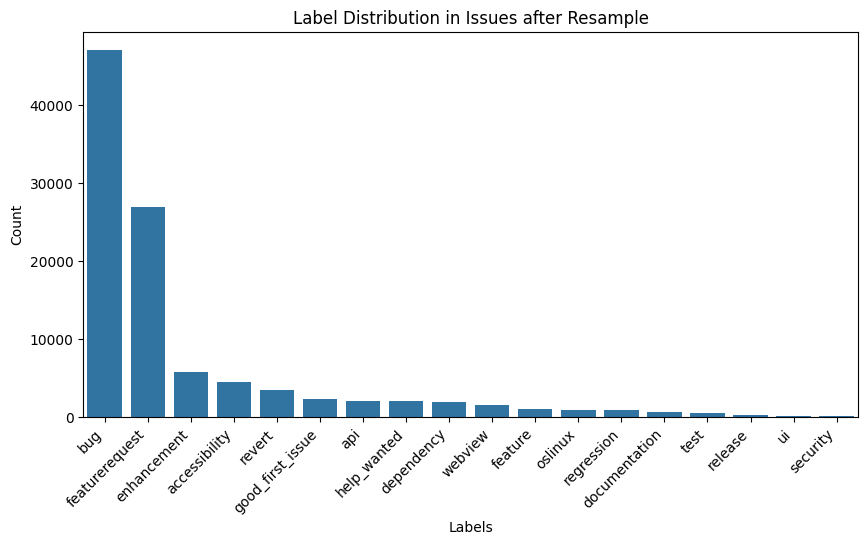

In [13]:
iss_df_maj = iss_df[iss_df[top_label_name] == 1]
iss_df_min = iss_df[iss_df[top_label_name] == 0]

iss_df_maj_downsamp = resample(
    iss_df_maj,
    replace=False,
    n_samples=len(iss_df_min),
    random_state=42
)

iss_df_balanced = pd.concat([iss_df_maj_downsamp, iss_df_min])
print(f"New dataset size after downsampling: {iss_df_balanced.shape}")

# Check label distribution
new_lab_dist = iss_df_balanced.iloc[:, 5:].sum().sort_values(ascending=False)
print(new_lab_dist)

# Plot label distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=new_lab_dist.index, y=new_lab_dist.values)
plt.xticks(rotation=45, ha="right")
plt.title("Label Distribution in Issues after Resample")
plt.ylabel("Count")
plt.xlabel("Labels")
plt.show()

In [26]:
new_total_labels = new_lab_dist.sum()
new_top_label_percentage = (new_lab_dist.iloc[0] / new_total_labels) * 100
new_top_label_name = new_lab_dist.index[0]
new_second_label_percentage = (new_lab_dist.iloc[1] / new_total_labels) * 100
new_second_label_name = new_lab_dist.index[1]
new_third_label_percentage = (new_lab_dist.iloc[2] / new_total_labels) * 100
new_third_label_name = new_lab_dist.index[2]
new_fourth_label_percentage = (new_lab_dist.iloc[3] / new_total_labels) * 100
new_fourth_label_name = new_lab_dist.index[3]
new_fifth_label_percentage = (new_lab_dist.iloc[4] / new_total_labels) * 100
new_fifth_label_name = new_lab_dist.index[4]
new_sixth_label_percentage = (new_lab_dist.iloc[5] / new_total_labels) * 100
new_sixth_label_name = new_lab_dist.index[5]

print(f"Top label ({new_top_label_name}) makes up {new_top_label_percentage:.2f}% of the dataset after resampling.")
print(f"Second-most label ({new_second_label_name}) makes up {new_second_label_percentage:.2f}% of the dataset after resampling.")
print(f"Third-most label ({new_third_label_name}) makes up {new_third_label_percentage:.2f}% of the dataset after resampling.")
print(f"Fourth-most label ({fourth_label_name}) makes up {fourth_label_percentage:.2f}% of the dataset after resampling.")
print(f"Fifth-most label ({fifth_label_name}) makes up {fifth_label_percentage:.2f}% of the dataset after resampling.")
print(f"Sixth-most label ({sixth_label_name}) makes up {sixth_label_percentage:.2f}% of the dataset after resampling.")

Top label (bug) makes up 46.15% of the dataset after resampling.
Second-most label (featurerequest) makes up 26.42% of the dataset after resampling.
Third-most label (enhancement) makes up 5.62% of the dataset after resampling.
Fourth-most label (accessibility) makes up 3.91% of the dataset after resampling.
Fifth-most label (revert) makes up 2.85% of the dataset after resampling.
Sixth-most label (good_first_issue) makes up 2.01% of the dataset after resampling.


### Get the number of unique labels

In [18]:
num_labels = iss_df_balanced.iloc[:, 5:].shape[1]
print(f"Number of unique labels: {num_labels}")

Number of unique labels: 18


### Split the dataset into train, validation, and test

In [20]:
# train/val split
iss_df_bal_train, iss_df_bal_temp = train_test_split(
    iss_df_balanced,
    test_size=0.3,
    random_state=42
)

# val/test split
iss_df_bal_val, iss_df_bal_test = train_test_split(
    iss_df_bal_temp,
    test_size=0.3,
    random_state=42
)

print(f"train DS size: {len(iss_df_bal_train)}")
print(f"val DS size: {len(iss_df_bal_val)}")
print(f"test DS size: {len(iss_df_bal_test)}")

train DS size: 65849
val DS size: 19754
test DS size: 8467


In [27]:
train_lab_dist = iss_df_bal_train.iloc[:, 5:].sum().sort_values(ascending=False)
val_lab_dist = iss_df_bal_val.iloc[:, 5:].sum().sort_values(ascending=False)
test_lab_dist = iss_df_bal_test.iloc[:, 5:].sum().sort_values(ascending=False)

train_total_labels = train_lab_dist.sum()
top_train_label_percentage = (train_lab_dist.iloc[0] / train_total_labels) * 100
top_train_label_name = train_lab_dist.index[0]
second_train_label_percentage = (train_lab_dist.iloc[1] / train_total_labels) * 100
second_train_label_name = train_lab_dist.index[1]
third_train_label_percentage = (train_lab_dist.iloc[2] / train_total_labels) * 100
third_train_label_name = train_lab_dist.index[2]
fourth_train_label_percentage = (train_lab_dist.iloc[3] / train_total_labels) * 100
fourth_train_label_name = train_lab_dist.index[3]
fifth_train_label_percentage = (train_lab_dist.iloc[4] / train_total_labels) * 100
fifth_train_label_name = train_lab_dist.index[4]
sixth_train_label_percentage = (train_lab_dist.iloc[5] / train_total_labels) * 100
sixth_train_label_name = train_lab_dist.index[5]

print(f"Top label ({top_train_label_name}) makes up {top_train_label_percentage:.2f}% of the train dataset.")
print(f"Second-most label ({second_train_label_name}) makes up {second_train_label_percentage:.2f}% of the train dataset.")
print(f"Third-most label ({third_train_label_name}) makes up {third_train_label_percentage:.2f}% of the train dataset.")
print(f"Fourth-most label ({fourth_train_label_name}) makes up {fourth_train_label_percentage:.2f}% of the train dataset.")
print(f"Fifth-most label ({fifth_train_label_name}) makes up {fifth_train_label_percentage:.2f}% of the train dataset.")
print(f"Sixth-most label ({sixth_train_label_name}) makes up {sixth_train_label_percentage:.2f}% of the train dataset.")

val_total_labels = val_lab_dist.sum()
top_val_label_percentage = (val_lab_dist.iloc[0] / val_total_labels) * 100
top_val_label_name = val_lab_dist.index[0]
second_val_label_percentage = (val_lab_dist.iloc[1] / val_total_labels) * 100
second_val_label_name = val_lab_dist.index[1]
third_val_label_percentage = (val_lab_dist.iloc[2] / val_total_labels) * 100
third_val_label_name = val_lab_dist.index[2]
fourth_val_label_percentage = (val_lab_dist.iloc[3] / val_total_labels) * 100
fourth_val_label_name = val_lab_dist.index[3]
fifth_val_label_percentage = (val_lab_dist.iloc[4] / val_total_labels) * 100
fifth_val_label_name = val_lab_dist.index[4]
sixth_val_label_percentage = (val_lab_dist.iloc[5] / val_total_labels) * 100
sixth_val_label_name = val_lab_dist.index[5]

print(f"Top label ({top_val_label_name}) makes up {top_val_label_percentage:.2f}% of the val dataset.")
print(f"Second-most label ({second_val_label_name}) makes up {second_val_label_percentage:.2f}% of the val dataset.")
print(f"Third-most label ({third_val_label_name}) makes up {third_val_label_percentage:.2f}% of the val dataset.")
print(f"Fourth-most label ({fourth_val_label_name}) makes up {fourth_val_label_percentage:.2f}% of the val dataset.")
print(f"Fifth-most label ({fifth_val_label_name}) makes up {fifth_val_label_percentage:.2f}% of the val dataset.")
print(f"Sixth-most label ({sixth_val_label_name}) makes up {sixth_val_label_percentage:.2f}% of the val dataset.")

test_total_labels = test_lab_dist.sum()
top_test_label_percentage = (test_lab_dist.iloc[0] / test_total_labels) * 100
top_test_label_name = test_lab_dist.index[0]
second_test_label_percentage = (test_lab_dist.iloc[1] / test_total_labels) * 100
second_test_label_name = test_lab_dist.index[1]
third_test_label_percentage = (test_lab_dist.iloc[2] / test_total_labels) * 100
third_test_label_name = test_lab_dist.index[2]
fourth_test_label_percentage = (test_lab_dist.iloc[3] / test_total_labels) * 100
fourth_test_label_name = test_lab_dist.index[3]
fifth_test_label_percentage = (test_lab_dist.iloc[4] / test_total_labels) * 100
fifth_test_label_name = test_lab_dist.index[4]
sixth_test_label_percentage = (test_lab_dist.iloc[5] / test_total_labels) * 100
sixth_test_label_name = test_lab_dist.index[5]

print(f"Top label ({top_test_label_name}) makes up {top_test_label_percentage:.2f}% of the test dataset.")
print(f"Second-most label ({second_test_label_name}) makes up {second_test_label_percentage:.2f}% of the test dataset.")
print(f"Third-most label ({third_test_label_name}) makes up {third_test_label_percentage:.2f}% of the test dataset.")
print(f"Fourth-most label ({fourth_test_label_name}) makes up {fourth_test_label_percentage:.2f}% of the test dataset.")
print(f"Fifth-most label ({fifth_test_label_name}) makes up {fifth_test_label_percentage:.2f}% of the test dataset.")
print(f"Sixth-most label ({sixth_test_label_name}) makes up {sixth_test_label_percentage:.2f}% of the test dataset.")

Top label (bug) makes up 46.18% of the train dataset.
Second-most label (featurerequest) makes up 26.50% of the train dataset.
Third-most label (enhancement) makes up 5.65% of the train dataset.
Fourth-most label (accessibility) makes up 4.33% of the train dataset.
Fifth-most label (revert) makes up 3.36% of the train dataset.
Sixth-most label (good_first_issue) makes up 2.22% of the train dataset.
Top label (bug) makes up 46.02% of the val dataset.
Second-most label (featurerequest) makes up 26.31% of the val dataset.
Third-most label (enhancement) makes up 5.41% of the val dataset.
Fourth-most label (accessibility) makes up 4.35% of the val dataset.
Fifth-most label (revert) makes up 3.44% of the val dataset.
Sixth-most label (good_first_issue) makes up 2.28% of the val dataset.
Top label (bug) makes up 46.15% of the test dataset.
Second-most label (featurerequest) makes up 26.09% of the test dataset.
Third-most label (enhancement) makes up 5.86% of the test dataset.
Fourth-most labe

In [19]:
# Write balance dataset to file
iss_ds_bal_train_json_str = iss_df_bal_train.to_json(
    orient="records",
    indent=4
)

iss_ds_bal_val_json_str = iss_df_bal_val.to_json(
    orient="records",
    indent=4
)

iss_ds_bal_test_json_str = iss_df_bal_test.to_json(
    orient="records",
    indent=4
)

with open("data/dataset_rebalanced_train.json", "w", encoding="utf-8") as f:
    f.write(iss_ds_bal_train_json_str)

with open("data/dataset_rebalanced_val.json", "w", encoding="utf-8") as f:
    f.write(iss_ds_bal_val_json_str)

with open("data/dataset_rebalanced_test.json", "w", encoding="utf-8") as f:
    f.write(iss_ds_bal_test_json_str)

In [31]:
# Assuming df is your DataFrame and label columns start at index 5 (adjust as needed)
train_label_cols = iss_df_bal_train.columns[5:]  # or explicitly list: ['bug', 'enhancement', ...]

# Count how many labels are assigned per issue
iss_df_bal_train['label_count'] = iss_df_bal_train[train_label_cols].sum(axis=1)

# Count number of issues by label count
train_label_count_distribution = iss_df_bal_train['label_count'].value_counts().sort_index()

# Assuming df is your DataFrame and label columns start at index 5 (adjust as needed)
val_label_cols = iss_df_bal_val.columns[5:]  # or explicitly list: ['bug', 'enhancement', ...]

# Count how many labels are assigned per issue
iss_df_bal_val['label_count'] = iss_df_bal_val[val_label_cols].sum(axis=1)

# Count number of issues by label count
val_label_count_distribution = iss_df_bal_val['label_count'].value_counts().sort_index()

# Assuming df is your DataFrame and label columns start at index 5 (adjust as needed)
test_label_cols = iss_df_bal_test.columns[5:]  # or explicitly list: ['bug', 'enhancement', ...]

# Count how many labels are assigned per issue
iss_df_bal_test['label_count'] = iss_df_bal_test[test_label_cols].sum(axis=1)

# Count number of issues by label count
test_label_count_distribution = iss_df_bal_test['label_count'].value_counts().sort_index()

print(train_label_count_distribution)
print(val_label_count_distribution)
print(test_label_count_distribution)

label_count
1    60873
2     4535
3      432
4        9
Name: count, dtype: int64
label_count
1    18183
2     1429
3      138
4        4
Name: count, dtype: int64
label_count
1    7815
2     591
3      60
4       1
Name: count, dtype: int64
